In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import randint, uniform
from sklearn import naive_bayes, linear_model, model_selection, metrics, tree, preprocessing
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier, GradientBoostingClassifier, StackingClassifier
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold, train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score, classification_report, roc_auc_score, roc_curve, auc, precision_score, recall_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics.pairwise import euclidean_distances

import torch
import torchvision
import torchvision.transforms as transforms
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F

import keras
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Conv2D, MaxPool2D, Flatten, Dropout, BatchNormalization
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
import cv2
from scipy.ndimage import gaussian_filter, map_coordinates
from keras.optimizers import Adam, RMSprop
from keras.callbacks import EarlyStopping, ReduceLROnPlateau
from sklearn.model_selection import train_test_split
import optuna
from optuna.integration import TFKerasPruningCallback

from tensorflow.keras.applications import ResNet50
from tensorflow.keras.layers import GlobalAveragePooling2D, Input, UpSampling2D
from tensorflow.keras.callbacks import ModelCheckpoint

d:\dev_tools\python\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Loading the dataset <br>
Removing rows not required, generating required features

In [2]:
df = pd.read_csv('transactions.csv')

#task 1: remove rows with missing customer IDs
df_filtered = df.dropna(subset=['Customer ID']) #removes 135080 rows with missing customer IDs

#task 2: remove rows with cancelled transactions
df_filtered2 = df_filtered[~df_filtered['Invoice'].str.startswith('C', na=False)] #removes 8905 rows with cancelled transactions (invoice starting with c)

#task 3: split dataframe into historical and future dataframes(based on 1st June 2011)
df_filtered2['InvoiceDate'] = pd.to_datetime(df_filtered2['InvoiceDate'])
date = pd.Timestamp('2011-06-01')
df_historical = df_filtered2[df_filtered2['InvoiceDate'] < date]
df_future = df_filtered2[df_filtered2['InvoiceDate'] >= date]

#task 4: creating df_train from customer IDs in df_historical, and target=1 if purchases after 1st June 2011 (i.e., df_future)
df_train = pd.DataFrame(df_historical['Customer ID'].unique(), columns=['Customer ID'])
df_train['target'] = df_train['Customer ID'].apply(lambda x: 1 if x in df_future['Customer ID'].values else 0)

#task 5: generating features
#total amount of historical transcations
df_train['TotalAmount'] = df_train['Customer ID'].map(df_historical.groupby('Customer ID')['Price'].sum())
#total number of historical transactions at invoice level
df_train['TotalTransactions'] = df_train['Customer ID'].map(df_historical.groupby('Customer ID')['Invoice'].nunique())
#number of unique items for each customer
df_train['UniqueItems'] = df_train['Customer ID'].map(df_historical.groupby('Customer ID')['StockCode'].nunique())

#5 more features from historical data
#total quantity of items purchased for each customer
df_train['TotalQuantity'] = df_train['Customer ID'].map(df_historical.groupby('Customer ID')['Quantity'].sum())
#average amount per transaction for each customer
df_train['AvgAmountPerTransaction'] = df_train['Customer ID'].map(df_historical.groupby('Customer ID')['Price'].mean())
#total number of different countries where the customer made purchases
df_train['TotalCountries'] = df_train['Customer ID'].map(df_historical.groupby('Customer ID')['Country'].nunique())
#average quantity purchased per unique item for each customer
df_train['AvgQuantityPerItem'] = df_train['Customer ID'].map(df_historical.groupby(['Customer ID', 'StockCode'])['Quantity'].mean().groupby('Customer ID').mean())
#average number of items purchased per transaction for each customer
df_train['AvgBasketSize'] = df_train['Customer ID'].map(df_historical.groupby('Customer ID')['Quantity'].mean())

C:\Users\glsam\AppData\Local\Temp\ipykernel_1344\2206934395.py:10: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df_filtered2['InvoiceDate'] = pd.to_datetime(df_filtered2['InvoiceDate'])
C:\Users\glsam\AppData\Local\Temp\ipykernel_1344\2206934395.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_filtered2['InvoiceDate'] = pd.to_datetime(df_filtered2['InvoiceDate'])


In [3]:
df_train.head

<bound method NDFrame.head of       Customer ID  target  TotalAmount  TotalTransactions  UniqueItems  \
0         17850.0       0      1176.23                 34           21   
1         13047.0       1       425.34                  7           72   
2         12583.0       1        99.14                  2           38   
3         13748.0       1        63.40                  4           18   
4         15100.0       1        21.90                  2            1   
...           ...     ...          ...                ...          ...   
2862      12367.0       0        35.20                  1           11   
2863      13079.0       1         1.25                  1            1   
2864      14629.0       1       204.54                  1           66   
2865      15274.0       1        48.56                  1           22   
2866      17383.0       0        94.68                  1           49   

      TotalQuantity  AvgAmountPerTransaction  TotalCountries  \
0              17

Split df_train into train and test <br>
Ensemble models (Random Forest)

In [348]:
#task 6: splitting the dataframe into train and test
train, test = model_selection.train_test_split(df_train, test_size=0.2, random_state=2024)

#task 7: RandomizedSearchCV to find best parameter combination
parameters = {
    'criterion': ['gini', 'entropy'], 
    'n_estimators': randint(100, 500),  
    'max_depth': randint(10, 50),       
    'min_samples_split': [2,3,4,5,6,7,8,9,10],
    'min_samples_leaf': [1,2,3,4,5,6,7,8,9,10],
    'max_features': ['sqrt', 'log2', None],
}

rf = RandomForestClassifier(random_state=2024)

rd_clf = RandomizedSearchCV(
    rf,
    parameters,
    n_iter=20,
    cv=StratifiedKFold(n_splits=10, shuffle=True, random_state=2024),
    random_state=2023,
    n_jobs=-1, 
    verbose=2  
)

X_train = train.drop(columns=['Customer ID', 'target'])
y_train = train['target']
X_test = test.drop(columns=['Customer ID', 'target'])
y_test = test['target']

rd_clf.fit(X_train, y_train)

print("Best parameters found by RandomizedSearchCV: ", rd_clf.best_params_)

test_score = rd_clf.score(X_test, y_test)
print("Accuracy on test set: ", test_score)

Fitting 10 folds for each of 20 candidates, totalling 200 fits
Best parameters found by RandomizedSearchCV:  {'criterion': 'gini', 'max_depth': 25, 'max_features': 'sqrt', 'min_samples_leaf': 9, 'min_samples_split': 9, 'n_estimators': 307}
Accuracy on test set:  0.7020905923344948


Ensemble Models (Extra Tree)

In [349]:
parameters2 = {
    'n_estimators': randint(100, 500),
    'max_depth': randint(10, 50),     
    'min_samples_split': [2,3,4,5,6,7,8,9,10],
    'min_samples_leaf': [1,2,3,4,5,6,7,8,9,10], 
    'max_features': ['sqrt', 'log2', None],
}

et = ExtraTreesClassifier(random_state=2024)

rd_clf2 = RandomizedSearchCV(
    et,
    parameters2,
    n_iter=20,
    cv=StratifiedKFold(n_splits=10, shuffle=True, random_state=2023),
    random_state=2024,
    n_jobs=-1,  
    verbose=2   
)

X_train = train.drop(columns=['Customer ID', 'target'])
y_train = train['target']
X_test = test.drop(columns=['Customer ID', 'target'])
y_test = test['target']

rd_clf2.fit(X_train, y_train)

print("Best parameters found: ", rd_clf2.best_params_)

test_score = rd_clf2.score(X_test, y_test)
print("Test set accuracy: ", test_score)

Fitting 10 folds for each of 20 candidates, totalling 200 fits
Best parameters found:  {'max_depth': 16, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 10, 'n_estimators': 287}
Test set accuracy:  0.7299651567944251


Ensemble Models (Gradient Boosting)

In [350]:
parameters3 = {
    'n_estimators': randint(100, 500),         
    'max_depth': randint(3, 10),               
    'min_samples_split': randint(2, 10),       
    'min_samples_leaf': randint(1, 10),        
    'learning_rate': uniform(0.01, 0.1),       
    'subsample': uniform(0.7, 0.3),            
    'max_features': ['sqrt', 'log2', None]     
}

gb = GradientBoostingClassifier(random_state=2023)

rd_clf3 = RandomizedSearchCV(
    gb,
    parameters3,
    n_iter=20,  # Number of parameter settings that are sampled
    cv=StratifiedKFold(n_splits=10, shuffle=True, random_state=2023),
    random_state=2023,
    n_jobs=-1,  
    verbose=2   
)

X_train = train.drop(columns=['Customer ID', 'target'])
y_train = train['target']
X_test = test.drop(columns=['Customer ID', 'target'])
y_test = test['target']

rd_clf3.fit(X_train, y_train)

print("Best parameters found: ", rd_clf3.best_params_)

test_score = rd_clf3.score(X_test, y_test)
print("Test set accuracy: ", test_score)

Fitting 10 folds for each of 20 candidates, totalling 200 fits
Best parameters found:  {'learning_rate': 0.019167672210207168, 'max_depth': 3, 'max_features': 'log2', 'min_samples_leaf': 7, 'min_samples_split': 9, 'n_estimators': 307, 'subsample': 0.7379493965285702}
Test set accuracy:  0.7195121951219512


5 most important features of Random Forest Classifier

In [351]:
best_rf = rd_clf.best_estimator_  #rd_clf is the RandomizedSearchCV instance used for random forest
feature_importances = best_rf.feature_importances_

feature_importances_df = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': feature_importances
})

feature_importances_df = feature_importances_df.sort_values(by='Importance', ascending=False)
top_5 = feature_importances_df.head(5)

print("5 most important features:")
print(top_5)

5 most important features:
                   Feature  Importance
3            TotalQuantity    0.189118
1        TotalTransactions    0.162696
0              TotalAmount    0.144525
4  AvgAmountPerTransaction    0.136006
2              UniqueItems    0.129084


Stacking model based on above classifiers <br>
Reporting the model performances on train and test sets for all individual and meta classifiers

In [357]:
base_classifiers = [
    ('RandomForest', rd_clf.best_estimator_),
    ('ExtraTree', rd_clf2.best_estimator_),
    ('GradientBoost', rd_clf3.best_estimator_)
]

meta_classifier = LogisticRegression(random_state=2024)

#stacking classifier
stacking = StackingClassifier(
    estimators=base_classifiers,
    final_estimator=meta_classifier,
    cv=5,
    n_jobs=-1
)

def evaluate_classifier(name, clf, X_train, y_train, X_test, y_test):
    clf.fit(X_train, y_train)
    y_train_pred = clf.predict(X_train)
    y_train_pred_proba = clf.predict_proba(X_train)[:, 1]
    y_test_pred = clf.predict(X_test)
    y_test_pred_proba = clf.predict_proba(X_test)[:, 1]
    
    metrics = {
        'Model': name,
        'Train_F1': f1_score(y_train, y_train_pred),
        'Train_Precision': precision_score(y_train, y_train_pred),
        'Train_Recall': recall_score(y_train, y_train_pred),
        'Train_ROC_AUC': roc_auc_score(y_train, y_train_pred_proba),
        'Test_F1': f1_score(y_test, y_test_pred),
        'Test_Precision': precision_score(y_test, y_test_pred),
        'Test_Recall': recall_score(y_test, y_test_pred),
        'Test_ROC_AUC': roc_auc_score(y_test, y_test_pred_proba)
    }
    
    return metrics

results = []
for name, clf in base_classifiers: #evaluating each classifier
    metrics = evaluate_classifier(name, clf, X_train, y_train, X_test, y_test)
    results.append(metrics)

stacking_metrics = evaluate_classifier('Stacking', stacking, X_train, y_train, X_test, y_test)
results.append(stacking_metrics)

results_df = pd.DataFrame(results).set_index('Model')
results_df

,Train_F1,Train_Precision,Train_Recall,Train_ROC_AUC,Test_F1,Test_Precision,Test_Recall,Test_ROC_AUC
Model,,,,,,,,
RandomForest,0.876271,0.801965,0.965753,0.895956,0.815534,0.744094,0.902148,0.686242
ExtraTree,0.829925,0.710235,0.998132,0.811299,0.843276,0.731579,0.995227,0.701917
GradientBoost,0.842048,0.751343,0.957659,0.804510,0.829268,0.746183,0.933174,0.703226
Stacking,0.850766,0.748699,0.985056,0.837914,0.827225,0.736940,0.942721,0.699931


ROC curve of all models on test set

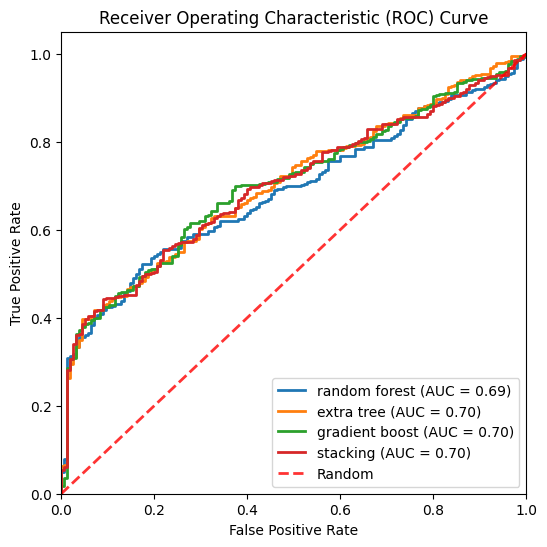

In [362]:
best_rf_model = rd_clf.best_estimator_
rf_pred_proba = best_rf_model.predict_proba(X_test)[:, 1]
best_et_model = rd_clf2.best_estimator_
et_pred_proba = best_et_model.predict_proba(X_test)[:, 1]
best_gb_model = rd_clf3.best_estimator_
gb_pred_proba = best_gb_model.predict_proba(X_test)[:, 1]
stk_pred_proba = stacking.predict_proba(X_test)[:, 1]

models = [
    ('random forest', rf_pred_proba),
    ('extra tree', et_pred_proba),
    ('gradient boost', gb_pred_proba),
    ('stacking', stk_pred_proba)
]

plt.figure(figsize=(6, 6))

for model_name, y_pred_proba in models:
    fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, lw=2, label=f'{model_name} (AUC = {roc_auc:.2f})')

plt.plot([0, 1], [0, 1], linestyle='--', lw=2, color='r', label='Random', alpha=.8)

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc="lower right")
plt.show()